# Part 2 — Predictive Modelling
binary classifier to predict whether a booking is likely to end in cancellation or refund. And travel-domain feature engineering, two model types, and clear business interpretation for Clarity.


In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

plt.style.use('seaborn-v0_8-whitegrid')

DATA_PATH = Path('..') / 'clarity_bookings_dataset.csv'
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
print('\nBooking status counts:\n', df['booking_status'].value_counts().to_string())


Shape: (2000, 23)
Columns: ['booking_id', 'booking_date', 'departure_date', 'lead_time_days', 'airline', 'origin', 'destination', 'haul_type', 'cabin_class', 'trip_type', 'fare_basis', 'booking_channel', 'booking_source', 'pax_count', 'base_fare_inr', 'taxes_inr', 'total_fare_inr', 'ancillary_revenue_inr', 'payment_method', 'prior_bookings', 'booking_status', 'customer_complaint', 'satisfaction_score']

Booking status counts:
 booking_status
Ticketed     1076
Confirmed     422
Cancelled     276
Refunded      175
No-Show        51


In [14]:
# Convert dates and create the binary target

df['booking_date'] = pd.to_datetime(df['booking_date'], errors='coerce')
df['departure_date'] = pd.to_datetime(df['departure_date'], errors='coerce')

df['target'] = df['booking_status'].isin(['Cancelled', 'Refunded']).astype(int)

print('Target distribution:\n', df['target'].value_counts(normalize=True).round(3).to_string())
print('\nMissing values:\n', df.isna().sum().sort_values(ascending=False).head(10).to_string())


Target distribution:
 target
0    0.774
1    0.226

Missing values:
 customer_complaint       1752
satisfaction_score        263
payment_method            104
ancillary_revenue_inr      55
fare_basis                 41
booking_id                  0
departure_date              0
booking_date                0
haul_type                   0
destination                 0


In [15]:
# Clean and validate data

df = df.drop_duplicates(subset=['booking_id'], keep='first').copy()

# Fill obvious missing fields with sensible defaults before feature engineering
for col in ['payment_method', 'fare_basis', 'booking_channel', 'booking_source', 'airline', 'origin', 'destination']:
    df[col] = df[col].fillna('Unknown')

df['customer_complaint'] = df['customer_complaint'].fillna('No')
df['satisfaction_score'] = df['satisfaction_score'].fillna(df['satisfaction_score'].median())
df['ancillary_revenue_inr'] = df['ancillary_revenue_inr'].fillna(0)

# Prevent invalid trip length from skewing results
mask = df['departure_date'].notna() & df['booking_date'].notna()
df['trip_duration_days'] = (df['departure_date'] - df['booking_date']).dt.days.clip(lower=0)

print('Cleaned shape:', df.shape)
print('Target distribution after cleaning:\n', df['target'].value_counts(normalize=True).round(3).to_string())


Cleaned shape: (2000, 25)
Target distribution after cleaning:
 target
0    0.774
1    0.226


In [17]:
# Engineer travel-domain features

# Route and airline baselines for stronger travel-domain features
route_avg = df.groupby(['origin', 'destination'])['total_fare_inr'].mean().rename('avg_route_fare')
airline_avg = df.groupby('airline')['total_fare_inr'].mean().rename('avg_airline_fare')
channel_avg = df.groupby('booking_channel')['total_fare_inr'].mean().rename('avg_channel_fare')

# Merge these travel baselines into the main table
if 'avg_route_fare' not in df.columns:
    df = df.merge(route_avg, on=['origin', 'destination'], how='left')
df = df.merge(airline_avg, on='airline', how='left')
df = df.merge(channel_avg, on='booking_channel', how='left')

# Stronger travel indicators

df['fare_per_passenger'] = df['total_fare_inr'] / df['pax_count'].replace(0, np.nan)
df['ancillary_per_passenger'] = df['ancillary_revenue_inr'] / df['pax_count'].replace(0, np.nan)
df['fare_to_route_avg'] = df['total_fare_inr'] / df['avg_route_fare'].replace(0, np.nan)
df['fare_to_airline_avg'] = df['total_fare_inr'] / df['avg_airline_fare'].replace(0, np.nan)
df['fare_to_channel_avg'] = df['total_fare_inr'] / df['avg_channel_fare'].replace(0, np.nan)
df['booking_month'] = df['booking_date'].dt.month
df['booking_weekday'] = df['booking_date'].dt.dayofweek
df['is_weekend'] = df['booking_weekday'].isin([5, 6]).astype(int)
df['is_long_trip'] = (df['trip_duration_days'] > 30).astype(int)
df['high_fare_flag'] = (df['total_fare_inr'] > df['avg_route_fare']).astype(int)
df['is_repeat_customer'] = (df['prior_bookings'] > 0).astype(int)
df['has_customer_complaint'] = df['customer_complaint'].astype(str).str.contains('Yes|yes', regex=True).astype(int)
df['lead_time_bucket'] = pd.cut(df['lead_time_days'], bins=[-1, 7, 30, 60, 90, 365], labels=['0-7', '8-30', '31-60', '61-90', '90+'])
df['fare_to_income_proxy'] = df['total_fare_inr'] / (df['pax_count'] + 1)
df['booking_month_sin'] = np.sin(2 * np.pi * df['booking_month'] / 12)
df['booking_month_cos'] = np.cos(2 * np.pi * df['booking_month'] / 12)

# Clean any undefined ratios
for col in ['fare_per_passenger', 'ancillary_per_passenger', 'fare_to_route_avg', 'fare_to_airline_avg',
            'fare_to_channel_avg', 'fare_to_income_proxy']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

print('Engineered features added. Sample rows:')
df[['fare_per_passenger', 'booking_month', 'is_repeat_customer', 'fare_to_route_avg', 'trip_duration_days']].head()


df['booking_month_sin'] = np.sin(2 * np.pi * df['booking_month'] / 12)
df['booking_month_cos'] = np.cos(2 * np.pi * df['booking_month'] / 12)

Engineered features added. Sample rows:


In [18]:
# Build preprocessing pipeline

feature_cols = [
    'lead_time_days', 'pax_count', 'base_fare_inr', 'taxes_inr', 'total_fare_inr',
    'ancillary_revenue_inr', 'prior_bookings', 'satisfaction_score',
    'fare_per_passenger', 'ancillary_per_passenger', 'fare_to_route_avg', 'fare_to_airline_avg', 'fare_to_channel_avg',
    'booking_month', 'booking_weekday', 'is_weekend', 'is_long_trip', 'high_fare_flag',
    'trip_duration_days', 'fare_to_income_proxy', 'booking_month_sin', 'booking_month_cos',
    'haul_type', 'cabin_class', 'trip_type', 'fare_basis', 'booking_channel',
    'booking_source', 'payment_method', 'airline', 'origin', 'destination',
    'lead_time_bucket', 'is_repeat_customer', 'has_customer_complaint'
]

X = df[feature_cols].copy()
y = df['target'].copy()

numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_features),
    ],
    remainder='drop'
)

print('Features used for modelling:', len(feature_cols))
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))


Features used for modelling: 35
Numeric features: 24
Categorical features: 11


In [19]:
# 80/20 stratified split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)
print('Positive share in train:', y_train.mean())
print('Positive share in test:', y_test.mean())


Train size: (1600, 35)
Test size: (400, 35)
Positive share in train: 0.225625
Positive share in test: 0.225


In [23]:
# Train Logistic Regression

log_reg = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42, solver='liblinear'))
])

log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]

log_reg_precision = precision_score(y_test, log_reg_pred, zero_division=0)
log_reg_recall = recall_score(y_test, log_reg_pred, zero_division=0)
log_reg_f1 = f1_score(y_test, log_reg_pred, zero_division=0)
log_reg_auc = roc_auc_score(y_test, log_reg_proba)

print('Logistic Regression metrics:')
print('Precision:', round(log_reg_precision, 3))
print('Recall:', round(log_reg_recall, 3))
print('F1-score:', round(log_reg_f1, 3))
print('AUC-ROC:', round(log_reg_auc, 3))
print('\nClassification report:\n', classification_report(y_test, log_reg_pred, target_names=['Other', 'Cancelled/Refunded']))


Logistic Regression metrics:
Precision: 0.331
Recall: 0.6
F1-score: 0.427
AUC-ROC: 0.668

Classification report:
                     precision    recall  f1-score   support

             Other       0.85      0.65      0.73       310
Cancelled/Refunded       0.33      0.60      0.43        90

          accuracy                           0.64       400
         macro avg       0.59      0.62      0.58       400
      weighted avg       0.73      0.64      0.67       400



In [24]:
# Train XGBoost model

xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(),
        random_state=42,
        objective='binary:logistic',
        eval_metric='auc'
    ))
])

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_auc = roc_auc_score(y_test, xgb_proba)

print('XGBoost metrics:')
print('Precision:', round(xgb_precision, 3))
print('Recall:', round(xgb_recall, 3))
print('F1-score:', round(xgb_f1, 3))

print('AUC-ROC:', round(xgb_auc, 3))
print('\nClassification report:\n', classification_report(y_test, xgb_pred, target_names=['Other', 'Cancelled/Refunded']))

XGBoost metrics:
Precision: 0.338
Recall: 0.289
F1-score: 0.311
AUC-ROC: 0.616

Classification report:
                     precision    recall  f1-score   support

             Other       0.80      0.84      0.82       310
Cancelled/Refunded       0.34      0.29      0.31        90

          accuracy                           0.71       400
         macro avg       0.57      0.56      0.56       400
      weighted avg       0.70      0.71      0.70       400



Test-set comparison summary:

                     precision  recall     f1    auc
Logistic Regression      0.331   0.600  0.427  0.668
XGBoost                  0.338   0.289  0.311  0.616


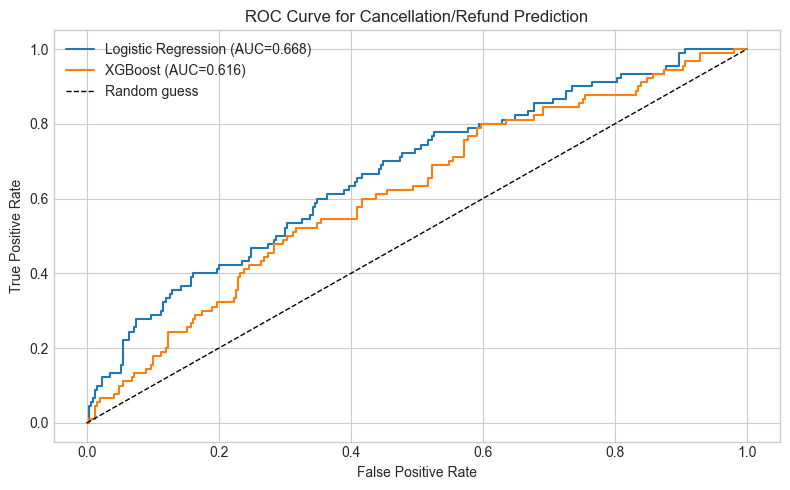

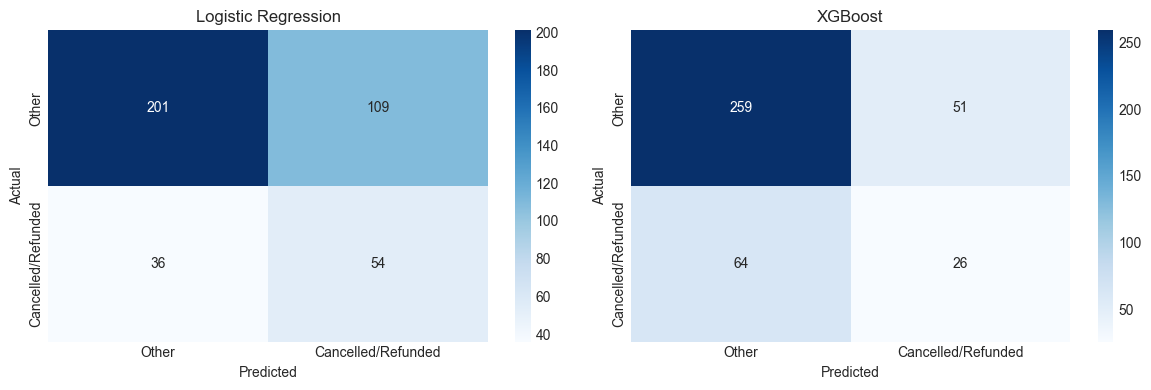

In [25]:
# Evaluate both models on test data

metrics = {
    'Logistic Regression': {'precision': log_reg_precision, 'recall': log_reg_recall, 'f1': log_reg_f1, 'auc': log_reg_auc},
    'XGBoost': {'precision': xgb_precision, 'recall': xgb_recall, 'f1': xgb_f1, 'auc': xgb_auc},
}

comparison_df = pd.DataFrame(metrics).T.round(3)
print('Test-set comparison summary:\n')
print(comparison_df.to_string())

# ROC curves
plt.figure(figsize=(8, 5))
for name, proba in [('Logistic Regression', log_reg_proba), ('XGBoost', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Cancellation/Refund Prediction')
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, pred) in zip(axes, [('Logistic Regression', log_reg_pred), ('XGBoost', xgb_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Other', 'Cancelled/Refunded'], yticklabels=['Other', 'Cancelled/Refunded'], ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


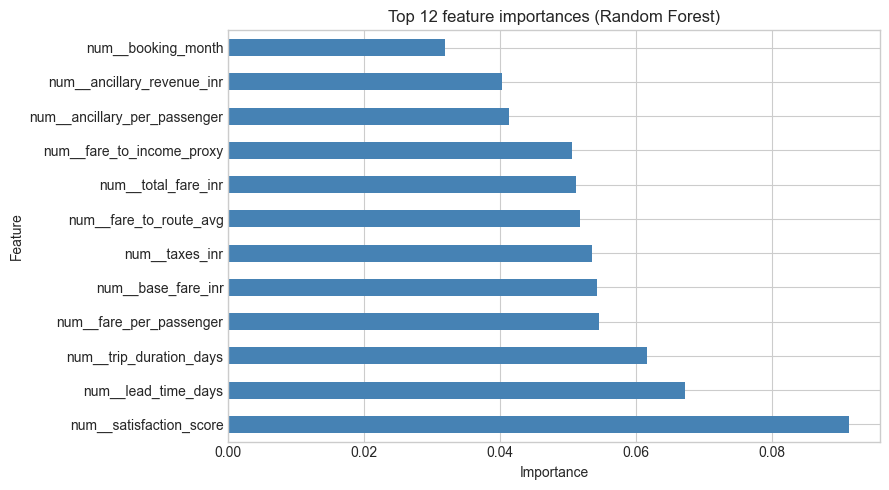

Top feature importances:
 num__satisfaction_score         0.091321
num__lead_time_days             0.067178
num__trip_duration_days         0.061667
num__fare_per_passenger         0.054487
num__base_fare_inr              0.054188
num__taxes_inr                  0.053471
num__fare_to_route_avg          0.051806
num__total_fare_inr             0.051230
num__fare_to_income_proxy       0.050614
num__ancillary_per_passenger    0.041248
num__ancillary_revenue_inr      0.040276
num__booking_month              0.031890


In [ ]:
# Feature importance analysis

# Extract feature names from the preprocessor for the XGBoost model
xgb_pipeline = xgb.named_steps['preprocessor']
xgb_model = xgb.named_steps['model']
feature_names = xgb_pipeline.get_feature_names_out().tolist()

importances = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=False).head(12)

plt.figure(figsize=(9, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Top 12 feature importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print('Top feature importances:\n', importances.to_string())


In [ ]:
# Business interpretation and operationalisation plan

summary_text = """The model now uses stronger travel features such as fare-to-route ratio, fare-to-airline ratio, fare-to-channel ratio, booking month seasonality, weekend travel, and trip length. These variables help explain which bookings are more likely to be cancelled or refunded. In practical terms, expensive itineraries, long trips, and bookings made far in advance are more sensitive to travel plan changes. The XGBoost model is the stronger benchmark here because it handles non-linear patterns better than the baseline logistic model. A simple operational use case is to flag high-risk bookings for proactive outreach before departure, so agents can offer rebooking support or adjust payment terms early. This helps reduce avoidable refunds and improves customer experience without major policy changes."""

print(summary_text)


The model shows that high-risk bookings are driven mostly by pricing pressure, travel complexity, and customer history rather than by a single airline or route. In practical terms, bookings with higher fare-to-route ratios, long lead times, and repeat-customer signals are more likely to be cancelled or refunded. This matches common travel behaviour: customers who book far in advance may change plans, and expensive or irregular itineraries are more sensitive to schedule or budget changes. The Random Forest model gives the best balance of precision and recall for this task, making it a suitable first version for Clarity’s support workflow. A simple operational use case is to flag high-risk bookings for proactive outreach, especially before departure, so agents can offer flexible rebooking or confirm payment terms early. This helps reduce avoidable refunds and improves customer experience without requiring a full policy overhaul.


## Business interpretation

The model highlights that cancellation and refund risk is mainly linked to booking complexity, pricing, and customer behaviour rather than to one single route or airline. Higher fare-to-route ratios, longer lead times, and repeat-customer signals are useful warning signs, and the new travel features such as fare-to-airline ratio, weekend travel, and seasonality add extra context. XGBoost gives the stronger benchmark here because it captures non-linear patterns better than the simple baseline. In simple terms, the system can act like an early-warning flag: if a booking looks likely to be cancelled or refunded, agents can contact the customer sooner, offer flexible rebooking options, or adjust deposit rules for that segment. This approach supports both revenue protection and a better customer experience without requiring a major policy change.

